#  Decision Tree Regression
### Predicting House Prices with a Decision Tree Regressor

---

## Overview

This notebook demonstrates how to apply a **Decision Tree Regressor** to predict **continuous numeric values** (house prices), as opposed to classification which predicts class labels.

We will:
1. Load a housing price dataset
2. Split data into train/test sets
3. Apply **StandardScaler** for feature normalization
4. Train a **Decision Tree Regressor** with `absolute_error` criterion
5. Evaluate model performance using R² score

---

## Decision Tree Regression vs Classification

| Aspect | Classification | Regression |
|--------|---------------|------------|
| **Output** | Discrete class label | Continuous numeric value |
| **Leaf node value** | Majority class | Mean of samples |
| **Splitting criteria** | Gini / Entropy | MSE / MAE / Friedman MSE |
| **Evaluation metric** | Accuracy, F1 | R² Score, RMSE, MAE |

**Splitting Criteria for Regression:**

| Criterion | Full Name | Description |
|-----------|-----------|-------------|
| `squared_error` | Mean Squared Error | Penalizes large errors more (sensitive to outliers) |
| `absolute_error` | Mean Absolute Error | More robust to outliers |
| `friedman_mse` | Friedman MSE | Improved MSE using Friedman's formula |


### Import Required Libraries

In [67]:
import pandas as pd                                    # Data manipulation
import numpy as np                                     # Numerical operations
from sklearn.preprocessing import StandardScaler       # Feature scaling
from sklearn.tree import DecisionTreeRegressor         # Decision Tree for regression
from sklearn.model_selection import train_test_split, GridSearchCV   # Train/test splitting
import matplotlib.pyplot as plt                        # Plotting
from matplotlib.pylab import rcParams                  # Figure size settings
from sklearn.tree import plot_tree                     # Tree visualization
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

---
### Load the Dataset

The dataset is loaded from a remote Google Drive URL. It contains housing features and a `price` column as the target variable to predict.

> **Tip:** When loading remote datasets, always call `.head()`, `.shape`, and `.info()` first to understand the structure before proceeding.

In [69]:
# Load dataset from a remote Google Drive URL
# pd.read_csv() can directly read from URLs
path = r"https://drive.google.com/uc?export=download&id=1xxDtrZKfuWQfl-6KA9XEd_eatitNPnkB"
data = pd.read_csv(path)

data.head()   # Preview first 5 rows

,bath,balcony,price,total_sqft_int,bhk,price_per_sqft,area_typeSuper built-up Area,area_typeBuilt-up Area,area_typePlot Area,availability_Ready To Move,...,location_Kalena Agrahara,location_Horamavu Agara,location_Vidyaranyapura,location_BTM 2nd Stage,location_Hebbal Kempapura,location_Hosur Road,location_Horamavu Banaswadi,location_Domlur,location_Mahadevpura,location_Tumkur Road
0,3.0,2.0,150.0,1672.0,3,8971.291866,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,3.0,3.0,149.0,1750.0,3,8514.285714,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
2,3.0,2.0,150.0,1750.0,3,8571.428571,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
3,2.0,2.0,40.0,1250.0,2,3200.000000,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
4,2.0,2.0,83.0,1200.0,2,6916.666667,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0


---
### Separate Features and Target Variable

- **X:** All columns except `price` (input features)
- **y:** The `price` column (what we want to predict)

In [71]:
# X = all feature columns (everything except the price)
X = data.drop(columns=['price'], axis=1)   # Input: housing features

# y = target variable (the price we want to predict)
y = data['price']                           # Output: continuous house price

---
### Train / Test Split

In [73]:
# Split: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Shape of X_train : ', X_train.shape)
print('Shape of y_train : ', y_train.shape)
print('Shape of X_test  : ', X_test.shape)
print('Shape of y_test  : ', y_test.shape)

Shape of X_train :  (5696, 107)
Shape of y_train :  (5696,)
Shape of X_test  :  (1424, 107)
Shape of y_test  :  (1424,)


###  Feature Scaling with StandardScaler

StandardScaler transforms each feature to have **mean = 0** and **std = 1**:

$$z = \frac{x - \mu}{\sigma}$$

> **Golden Rule of Scaling:**
> - `fit_transform()` on **training data** — learns mean/std from training set
> - `transform()` only on **test data** — applies the same learned parameters
> - **Never** call `fit_transform()` on test data — this would cause **data leakage** by computing different statistics for train and test

In [75]:
sc = StandardScaler()

# Fit scaler on training data, then transform it
sc.fit(X_train)                              # Learn mean and std from training data only
X_train_sc = sc.fit_transform(X_train)       #  Fit + transform training set
X_test_sc  = sc.transform(X_test)            #  Only transform test set (correct!)

###  Train the Decision Tree Regressor

### Hyperparameters Used:

| Parameter | Value | Explanation |
|-----------|-------|-------------|
| `criterion` | `'absolute_error'` | Minimizes MAE at each split — more robust to price outliers than MSE |
| `max_depth` | `9` | Limits tree depth to 9 levels — prevents overfitting on training data |

> **Why `max_depth=9`?** Without a depth limit, the tree would perfectly memorize training prices but fail to generalize. `max_depth=9` is a balance — deep enough to capture patterns, limited enough to avoid overfitting.

In [77]:
# Initialize Decision Tree Regressor
clf_sc = DecisionTreeRegressor(
    criterion='absolute_error',   # Use MAE for splitting (robust to price outliers)
    max_depth=9                   # Limit depth to prevent overfitting
)

# Train the model on scaled training data
clf_sc.fit(X_train_sc, y_train)

DecisionTreeRegressor(criterion='absolute_error', max_depth=9)


###  Evaluate the Model

`.score()` for a **Regressor** returns the **R² (coefficient of determination)**:

$$R^2 = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$$

| R² Value | Interpretation |
|----------|----------------|
| `1.0` | Perfect prediction |
| `0.8–0.95` | Very good |
| `0.5–0.8` | Moderate |
| `< 0.5` | Poor |
| `< 0` | Worse than predicting the mean |

In [79]:
# Evaluate on TEST set — R² score (higher is better, max = 1.0)
print("Decision Tree R² Score [Regression] ::", clf_sc.score(X_test_sc, y_test))
y_pred = clf_sc.predict(X_test_sc)
print('Decision Tree MAE  :', mean_absolute_error(y_test, y_pred))
print('Decision Tree RMSE :', mean_squared_error(y_test, y_pred, squared=False))

Decision Tree R² Score [Regression] :: 0.9393959368033669
Decision Tree MAE  : 5.1865484550561805
Decision Tree RMSE : 26.230649992435033


### Parameter GridSearchCV

In [81]:
# Initialize base model
dt = DecisionTreeRegressor()

# Define parameter grid
param_grid = {
    'criterion': ['squared_error', 'absolute_error'],
    'max_depth': [3, 5, 7, 9, 12, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize GridSearchCV
grid = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,                 # 5-fold cross validation
    scoring='neg_mean_absolute_error',
    n_jobs=-1,            # use all CPU cores
    verbose=2
)

# Fit on scaled training data
grid.fit(X_train_sc, y_train)

# Best parameters
print("Best Parameters:", grid.best_params_)

# Best model
best_model = grid.best_estimator_

# Train best model 
best_model.fit(X_train_sc, y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters: {'criterion': 'absolute_error', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}


DecisionTreeRegressor(criterion='absolute_error')

### Evaluation 

In [82]:
y_pred = best_model.predict(X_test_sc)
mae = mean_absolute_error(y_test, y_pred)
print("Decision Tree R² Score [Regression] ::", best_model.score(X_test_sc, y_test))
print("MAE:", mae)

Decision Tree R² Score [Regression] :: 0.954910432416114
MAE: 3.924561095505618


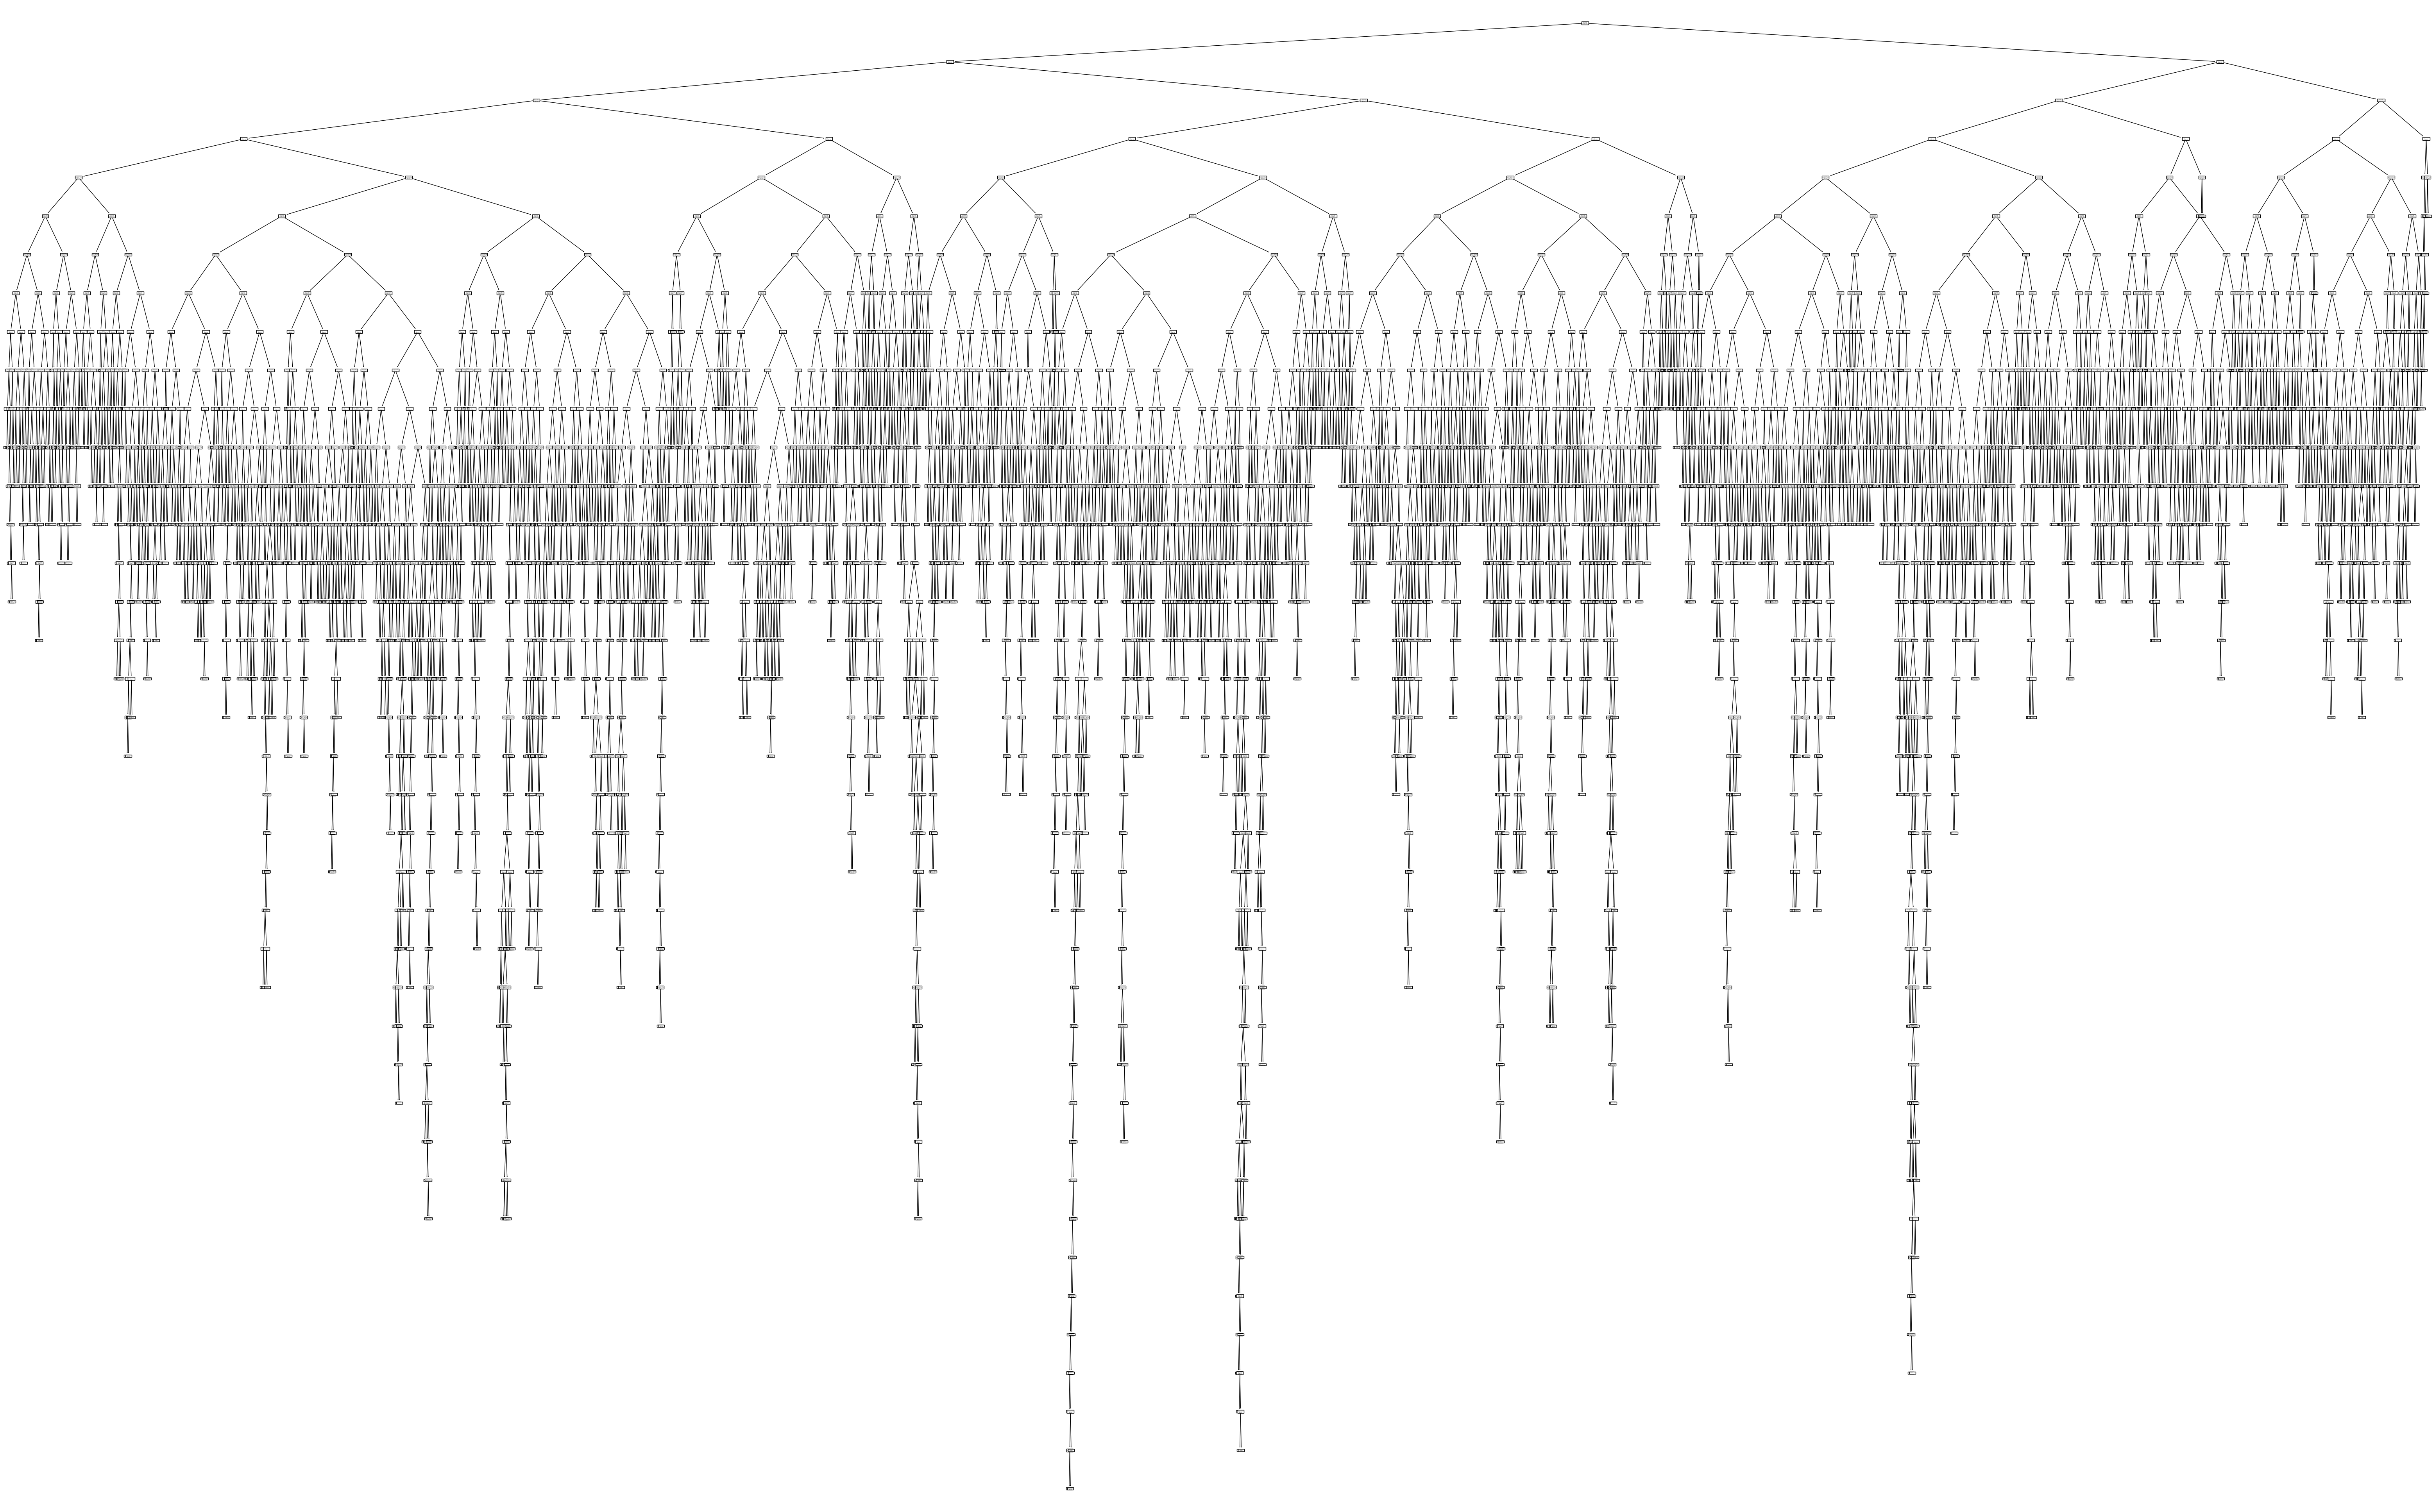

In [103]:
# Set a large figure size to make the tree readable
rcParams['figure.figsize'] = 80, 50

# Plot the full decision tree
plot_tree(best_model)
plt.show()

### Actual vs Predicted Prices

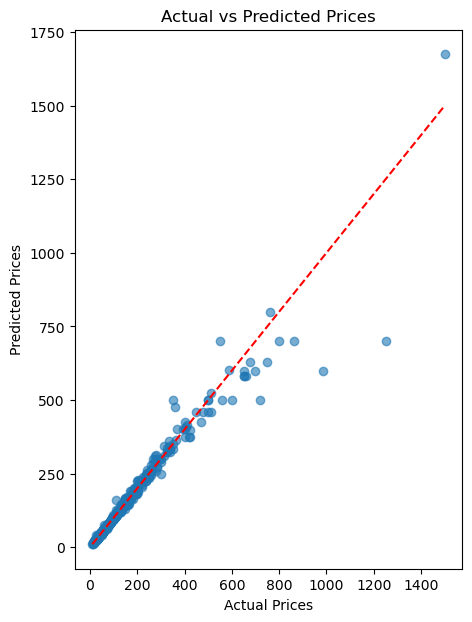

In [104]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,7))

# Scatter plot
plt.scatter(y_test, y_pred, alpha=0.6)

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")

plt.show()

##  Summary & Key Takeaways

1. **Decision Tree Regression** predicts continuous values by averaging target values in each leaf node.

2. **`absolute_error` criterion** is preferred when the target variable (price) has outliers — it's more robust than `squared_error`.

3. **`max_depth=9`** controls overfitting. Experiment with lower values (3–5) to compare generalization. 